# 🔬 Tiny U-Net Pipeline: ถ่ายภาพ Dataset จากกล้องสด + ฝึกสอนโมเดล + ตรวจจับ PCB แบบเรียลไทม์
> **รวมครบทุกขั้นตอนจบในไฟล์เดียว (All-in-One Self-Contained Notebook)**
> - **การถ่ายภาพ Dataset**: ใช้โหมดกล้องสดพร้อมกรอบเล็งเป้า (ROI Guide Box) ถ่ายง่าย เสถียร บันทึกภาพพร้อม Mask ทันที
> - **การตรวจจับตอนรัน AI**: ระบบจะค้นหาแผ่น PCB ตัดพื้นหลังออกอัตโนมัติ (Background Removal) และดึงเฉพาะตัวบอร์ดส่งเข้า AI

---

### 📋 สารบัญขั้นตอนการทำงาน:
1. **ตั้งค่าสภาพแวดล้อม & โฟลเดอร์ใหม่**: กำหนดชื่อโฟลเดอร์ เช่น `dataset_v4` สำหรับเก็บภาพชุดใหม่
2. **ระบบสกัด Mask ลายทองแดง (Copper Mask Engine)**: CIELAB Chroma-Hue Angle + Adaptive Otsu ทนแสงสะท้อน
3. **ฟังก์ชันถ่ายภาพ PCB จากกล้องสด (Camera Studio - แบบเล็งเป้าดั้งเดิม)**: แสดงกรอบเล็งเป้าตรงกลาง เล็งบอร์ดแล้วกด Space บันทึกพร้อม Mask
4. **รวม Dataset & ภาพสังเคราะห์เสริม**: รวบรวมคู่ภาพ Image-Mask สำหรับป้อนโมเดล
5. **Data Augmentation & PyTorch DataLoader**: จำลองแสงเงาพาดเฉียง, ความเบลอ, การสั่นไหวบนสายพาน
6. **สถาปัตยกรรมโมเดล Tiny U-Net (~1.9M Params)**: โมเดลขนาดกะทัดรัด ความเร็วสูง เหมาะสำหรับ Raspberry Pi 5
7. **Loss Function (BCE + Dice + clDice)**: clDice รักษาเส้นกลาง ป้องกันวงจรขาด (Open) หรือช็อต (Short)
8. **ขั้นตอนฝึกสอนโมเดล (Training Loop)**: OneCycleLR + Auto Best Checkpoint Saving
9. **ประเมินผล & Visual Inspection**: พล็อตกราฟ และเปรียบเทียบภาพจริงกับผลทำนาย
10. **ทดสอบ False Alarm เชิง Topology (Open / Short)**: วิเคราะห์โครงสร้างเส้นวงจร
11. **Export โมเดลเป็น ONNX**: ส่งออกเป็น `models/copper_unet.onnx`
12. **ระบบตรวจจับแผ่น PCB & ตรวจเช็คลายทองแดงแบบ Real-Time**: ตรวจจับและดึงเฉพาะตัวบอร์ด PCB ออกมาจากพื้นหลังสดๆ ผ่านกล้อง


In [22]:
# 1. ตรวจสอบและติดตั้งแพ็กเกจที่จำเป็น
# !pip install torch torchvision opencv-python scikit-image onnx onnxruntime matplotlib

import os
import sys
import glob
import time
import math
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ตรวจสอบ Device การประมวลผล
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Device ที่ใช้งาน: {device.upper()}")
if device == "cuda":
    print(f"   🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"   💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ⚠️ กำลังใช้ CPU ในการประมวลผล")


🖥️ Device ที่ใช้งาน: CUDA
   🚀 GPU: NVIDIA GeForce RTX 3060 Laptop GPU
   💾 VRAM: 6.09 GB


### ⚙️ กำหนดค่า Configuration & โฟลเดอร์สำหรับชุดข้อมูลใหม่
- `NEW_DATASET_NAME`: ชื่อโฟลเดอร์สำหรับชุดข้อมูลที่ถ่ายใหม่ (เช่น `dataset_v4` หรือ `dataset_fresh`)
- ระบบจะสร้างโฟลเดอร์ย่อยให้อัตโนมัติ:
  - `images/`: ภาพบอร์ด PCB ขนาด 256x256
  - `masks/`: Ground Truth Mask ลายทองแดง (255=ทองแดง, 0=เนื้อบอร์ด, 128=ขอบไม่คิดคะแนน)
  - `raw_images/`: ภาพต้นฉบับเต็มเฟรมจากกล้อง


In [23]:
# 📁 ตั้งชื่อโฟลเดอร์สำหรับชุดข้อมูลใหม่ที่ต้องการถ่ายใหม่ทั้งหมด
NEW_DATASET_NAME = "dataset_v4"

# ตรวจสอบ Root Directory อัตโนมัติ ไม่ว่าจะเปิดโน้ตบุ๊กจาก root หรือโฟลเดอร์ train_ai_pcb
current_dir = Path.cwd().resolve()
if (current_dir / "train_ai_pcb").exists():
    BASE_DIR = current_dir / "train_ai_pcb"
elif current_dir.name == "train_ai_pcb":
    BASE_DIR = current_dir
else:
    BASE_DIR = current_dir

DATASET_DIR = str(BASE_DIR / NEW_DATASET_NAME)
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
MASKS_DIR = os.path.join(DATASET_DIR, "masks")
RAW_DIR = os.path.join(DATASET_DIR, "raw_images")

# โฟลเดอร์ models
root_models = current_dir / "models" if (current_dir / "models").exists() else BASE_DIR / "models"
MODELS_DIR = str(root_models)
MODEL_PATH = os.path.join(MODELS_DIR, "copper_unet.pt")
ONNX_PATH = os.path.join(MODELS_DIR, "copper_unet.onnx")

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# พารามิเตอร์การฝึกสอน
CROP = 256                  # ขนาด Patch ภาพบอร์ด PCB (256x256)
BATCH = 16                  # Batch Size
EPOCHS = 50                 # จำนวน Epochs
LR = 2e-3                   # Learning Rate สูงสุด
VAL_RATIO = 0.15            # สัดส่วนแบ่งชุดทดสอบ (15%)
UNET_BASE = 16              # Base Channels โมเดล (16 = ~1.9M params เหมาะกับ Pi 5)
N_SYNTHETIC = 30            # จำนวนบอร์ดสังเคราะห์เสริม (ใส่ 0 หากต้องการใช้เฉพาะภาพถ่ายจริง)
W_CLDICE = 0.5              # น้ำหนัก clDice Loss
CL_WARMUP = 10              # เริ่มคำนวณ clDice หลัง epoch 10

NORM_MEAN = 0.5
NORM_STD = 0.25

print(f"📁 บันทึกข้อมูลที่: {DATASET_DIR}")
print(f"   ├── Images: {IMAGES_DIR}")
print(f"   ├── Masks:  {MASKS_DIR}")
print(f"   └── Raw:    {RAW_DIR}")
print(f"🎯 โมเดลจะถูกบันทึกที่: {MODEL_PATH}")


📁 บันทึกข้อมูลที่: /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/dataset_v4
   ├── Images: /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/dataset_v4/images
   ├── Masks:  /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/dataset_v4/masks
   └── Raw:    /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/dataset_v4/raw_images
🎯 โมเดลจะถูกบันทึกที่: /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/models/copper_unet.pt


## 1. ระบบสกัด Mask ลายทองแดง (Self-Contained Copper Mask Engine)
คำนวณแยกเนื้อทองแดงแท้ออกจากแผ่นบอร์ดด้วย **CIELAB Chroma-Hue Angle + Adaptive Otsu**:
- สกัด Mask 3 ระดับ: 255 (ทองแดง), 0 (เนื้อบอร์ด), 128 (ขอบรอยต่อไม่คิดคะแนน)


In [28]:
def disk(r):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))

def dil(m, r):
    return cv2.dilate(m, disk(r)) if r > 0 else m.copy()

def ero(m, r):
    return cv2.erode(m, disk(r)) if r > 0 else m.copy()

def remove_small(mask01, min_area=20):
    if min_area <= 0: return mask01
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask01.astype(np.uint8), connectivity=8)
    keep = np.zeros(n, np.uint8)
    keep[1:] = (st[1:, cv2.CC_STAT_AREA] >= min_area)
    return keep[lab]

def fill_small_holes(mask01, max_hole=10):
    inv = (1 - mask01).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)
    small = np.zeros(n, bool)
    small[1:] = st[1:, cv2.CC_STAT_AREA] < max_hole
    out = mask01.copy()
    out[small[lab]] = 1
    return out


def chroma_hue_angle(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    a = lab[..., 1] - 128.0
    b = lab[..., 2] - 128.0
    ang = np.degrees(np.arctan2(b, a))
    chroma = np.sqrt(a * a + b * b)
    return ang, chroma


def rgb_dominance_mask(img_bgr, r_margin=8.0):
    """
    เกณฑ์ที่สอง: ทองแดง (แม้จะหมอง/โดนเงา) จะยังมีช่อง Red สูงกว่า Green และ Blue
    อย่างสม่ำเสมอ ต่างจากเนื้อบอร์ดสีเหลือง ใช้ percentile ของภาพเองแทนค่าคงที่
    เพื่อให้ทนต่อสภาพแสงที่เปลี่ยนไปบนสายพาน
    """
    b, g, r = cv2.split(img_bgr.astype(np.float32))
    diff_rg = r - g
    diff_rb = r - b

    pos_rg = diff_rg[diff_rg > 0]
    adaptive_margin = max(r_margin, np.percentile(pos_rg, 40)) if pos_rg.size > 200 else r_margin

    return (diff_rg > adaptive_margin) & (diff_rb > adaptive_margin * 0.6)


def generate_copper_mask(
    board_bgr,
    chroma_min=6.0,          # ลดจาก 10.0 -> กู้คืนทองแดงที่หมอง/โดนเงา (chroma ต่ำ) ได้มากขึ้น
    thr_range=(40.0, 95.0),  # ขยายจาก (50,85) กัน Otsu ชนขอบแล้วตัดสีผิดทั้งภาพ
    ignore_band=4.0,
    min_area=20,
    return_label=True
):
    img_filtered = cv2.bilateralFilter(board_bgr, 7, 40, 7)
    ang, chroma = chroma_hue_angle(img_filtered)
    valid = chroma >= chroma_min
    ang_c = np.clip(ang, 0, 120)
    u8 = (ang_c / 120.0 * 255).astype(np.uint8)

    if valid.sum() > 100:
        t, _ = cv2.threshold(u8[valid].reshape(-1, 1), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr = float(t / 255.0 * 120.0)
        # ถ้า Otsu ชนขอบเขต แปลว่าภาพนี้ไม่ bimodal พอ -> ใช้ percentile แทน (กัน false "short")
        if thr <= thr_range[0] + 1e-3 or thr >= thr_range[1] - 1e-3:
            thr = float(np.percentile(ang_c[valid], 35))
        thr = float(np.clip(thr, *thr_range))
    else:
        thr = float(np.mean(thr_range))

    copper_by_hue = (ang_c < thr) & valid

    # เกณฑ์ที่สอง (RGB dominance) กู้คืนทองแดง chroma ต่ำที่ hue-angle เพียงอย่างเดียวพลาดไป
    copper_by_rgb = rgb_dominance_mask(img_filtered)

    # union: อย่างใดอย่างหนึ่งยืนยันว่าเป็นทองแดงก็นับ (ลด false "open")
    copper = copper_by_hue | copper_by_rgb
    m = copper.astype(np.uint8)

    # opening เบา ๆ ตัดจุดเชื่อมหลอกจากการ union แบบกว้าง (ลด false "short")
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, disk(1))
    m = cv2.medianBlur(m * 255, 3) // 255
    m = remove_small(m, min_area)
    m = fill_small_holes(m, max(4, min_area // 2))

    out = (m * 255).astype(np.uint8)
    if return_label:
        uncertain = (np.abs(ang_c - thr) < ignore_band) & (~copper_by_rgb) | ((~valid) & (~copper_by_rgb))
        edge = dil(m, 1) != ero(m, 1)
        out = out.copy()
        out[uncertain & edge] = 128
        out[(~valid) & (~copper_by_rgb) & (m == 0)] = 128

    return out


def generate_masks_for_folder(images_dir, masks_dir):
    os.makedirs(masks_dir, exist_ok=True)
    paths = sorted(glob.glob(os.path.join(images_dir, "*.png")) + glob.glob(os.path.join(images_dir, "*.jpg")))
    print(f"🔄 กำลังประมวลผลสร้าง Mask สำหรับ {len(paths)} ภาพ...")
    count = 0
    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        mask = generate_copper_mask(img, return_label=True)
        fname = Path(p).stem + ".png"
        cv2.imwrite(os.path.join(masks_dir, fname), mask)
        count += 1
    print(f"✅ สร้าง Mask สำเร็จ {count} ภาพ ลงใน {masks_dir}")

## 2. ฟังก์ชันถ่ายภาพ PCB จากกล้องสด (Camera Studio - แบบเล็งเป้าดั้งเดิมที่เสถียร)
เปิดหน้าต่างกล้องสดเพื่อถ่ายภาพชุดข้อมูล PCB โดยใช้ **กรอบเล็งเป้า (ROI Guide Box)** ที่ใช้งานง่าย เสถียร ไม่กระตุก:
- **กรอบเล็งเป้าตรงกลาง**: จัดวางบอร์ด PCB ให้อยู่ในกรอบสีเขียว
- **ปุ่มปรับขนาด**: กด `[+]` หรือ `[-]` เพื่อขยายหรือย่อกรอบเล็งเป้า
- **คลิกลากเมาส์**: วาดกรอบสี่เหลี่ยมครอบแผ่น PCB ได้อิสระตามต้องการ
- **ปุ่ม `[R]`**: รีเซ็ตกรอบกลับมาอยู่ตรงกลาง
- **ปุ่ม `[T]`**: สลับเปิด/ปิด Live Copper Trace Preview เพื่อดูตัวอย่างลายทองแดงสดก่อนกดถ่าย
- **ปุ่ม `[SPACE]` หรือ `[S]`**: บันทึกภาพลง `images/` ขนาด 256x256 และประมวลผลสร้าง Mask ลง `masks/` ทันที พร้อมเก็บภาพดิบลง `raw_images/`
- **ปุ่ม `[Q]` หรือ `[ESC]`**: ออกจากโปรแกรมเมื่อบันทึกเสร็จสิ้น


In [25]:
def find_working_camera(preferred_idx=None):
    """ค้นหากล้องที่เปิดใช้งานได้จริงในระบบ (ลอง 1, 0, 2, 3)"""
    candidates = [preferred_idx] if preferred_idx is not None else [1, 0, 2, 3]
    for idx in candidates:
        if idx is None: continue
        try:
            cap = cv2.VideoCapture(idx)
            if cap.isOpened():
                ret, frame = cap.read()
                cap.release()
                if ret and frame is not None:
                    return idx
        except Exception:
            pass
    return None


def capture_pcb_dataset(
    output_dir=DATASET_DIR,
    cam_idx=None,
    target_size=(256, 256)
):
    """
    เปิดหน้าต่างกล้องสด เล็งบอร์ด PCB ในกรอบ และกด [SPACE] เพื่อบันทึกภาพพร้อมสร้าง Mask ลายทองแดงทันที
    """
    images_dir = os.path.join(output_dir, "images")
    masks_dir = os.path.join(output_dir, "masks")
    raw_dir = os.path.join(output_dir, "raw_images")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(raw_dir, exist_ok=True)

    existing = glob.glob(os.path.join(images_dir, "pcb_*.png"))
    saved_count = len(existing)
    next_index = saved_count + 1

    active_cam = find_working_camera(cam_idx)
    if active_cam is None:
        print("❌ ไม่พบกล้องที่เปิดใช้งานได้ กรุณาตรวจสอบการเชื่อมต่อสายกล้อง USB")
        return

    cap = cv2.VideoCapture(active_cam)
    if not cap.isOpened():
        print(f"❌ ไม่สามารถเปิดกล้องหมายเลข {active_cam} ได้")
        return

    print(f"📷 เปิดกล้องหมายเลข {active_cam} สำเร็จ")
    print(f"📁 บันทึกข้อมูลลงโฟลเดอร์: {output_dir}")

    roi_box_size = 280
    manual_roi = None
    mouse_dragging = False
    drag_start = (0, 0)
    show_trace_preview = False
    notification_text = ""
    notification_time = 0

    def mouse_cb(event, x, y, flags, param):
        nonlocal mouse_dragging, drag_start, manual_roi
        if event == cv2.EVENT_LBUTTONDOWN:
            mouse_dragging = True
            drag_start = (x, y)
            manual_roi = None
        elif event == cv2.EVENT_MOUSEMOVE and mouse_dragging:
            manual_roi = (
                min(drag_start[0], x),
                min(drag_start[1], y),
                abs(x - drag_start[0]),
                abs(y - drag_start[1])
            )
        elif event == cv2.EVENT_LBUTTONUP:
            mouse_dragging = False
            w = abs(x - drag_start[0])
            h = abs(y - drag_start[1])
            if w > 20 and h > 20:
                manual_roi = (min(drag_start[0], x), min(drag_start[1], y), w, h)
            else:
                manual_roi = None

    window_name = "PCB Camera Capture Studio"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)
    cv2.setMouseCallback(window_name, mouse_cb)

    print("\n" + "=" * 65)
    print("  📸 หน้าต่างกล้องเริ่มทำงานแล้ว! (เล็งแผ่น PCB ให้อยู่ในกรอบ)")
    print("-----------------------------------------------------------------")
    print("  [SPACE] หรือ [S] : บันทึกภาพ PCB + สร้าง Mask ทองแดงลงโฟลเดอร์ทันที")
    print("  [T]              : สลับเปิด/ปิด Live Copper Trace Preview")
    print("  [+] / [-]        : ขยาย / ย่อ กรอบเล็งเป้าตรงกลาง")
    print("  [คลิกลากเมาส์]    : วาดกรอบครอบเฉพาะบอร์ด PCB เองตามใจชอบ")
    print("  [R]              : รีเซ็ตกรอบกลับมากึ่งกลาง")
    print("  [Q] หรือ [ESC]   : สิ้นสุดการถ่ายภาพและออกจากโปรแกรม")
    print("=" * 65 + "\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("⚠️ ไม่สามารถรับสัญญาณภาพจากกล้องได้")
            break

        h_frame, w_frame = frame.shape[:2]

        if manual_roi is not None:
            rx, ry, rw, rh = manual_roi
            rx = max(0, min(rx, w_frame - 1))
            ry = max(0, min(ry, h_frame - 1))
            rw = max(10, min(rw, w_frame - rx))
            rh = max(10, min(rh, h_frame - ry))
        else:
            bsize = min(roi_box_size, w_frame, h_frame)
            rx = (w_frame - bsize) // 2
            ry = (h_frame - bsize) // 2
            rw, rh = bsize, bsize

        display = frame.copy()

        # 1. แสดง Live Copper Trace Preview ถ้าเปิดใช้งาน
        if show_trace_preview:
            cropped = frame[ry:ry+rh, rx:rx+rw]
            if cropped.size > 0:
                resized_prev = cv2.resize(cropped, target_size)
                p_mask = generate_copper_mask(resized_prev, return_label=True)
                p_mask_full = cv2.resize((p_mask == 255).astype(np.uint8) * 255, (rw, rh), interpolation=cv2.INTER_NEAREST)
                overlay = cropped.copy()
                overlay[p_mask_full > 127] = [0, 255, 0]
                display[ry:ry+rh, rx:rx+rw] = cv2.addWeighted(cropped, 0.45, overlay, 0.55, 0)

        # 2. วาดกรอบเป้าหมาย
        box_color = (0, 255, 255) if manual_roi else (0, 255, 0)
        cv2.rectangle(display, (rx, ry), (rx + rw, ry + rh), box_color, 2)
        cv2.putText(display, f"PCB Target ({rw}x{rh})", (rx, max(22, ry - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, box_color, 2)

        # 3. แถบสถานะด้านบน
        cv2.rectangle(display, (0, 0), (w_frame, 36), (20, 20, 20), -1)
        stat = f"Saved: {saved_count} | [SPACE]: Save & Mask | [T]: Trace Preview | [Q]: Finish"
        cv2.putText(display, stat, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 255, 255), 1)

        # 4. การแจ้งเตือนเมื่อกดบันทึกสำเร็จ
        if time.time() - notification_time < 1.6:
            cv2.rectangle(display, (0, h_frame - 38), (w_frame, h_frame), (0, 150, 0), -1)
            cv2.putText(display, notification_text, (15, h_frame - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        cv2.imshow(window_name, display)
        key = cv2.waitKey(1) & 0xFF

        if key in [ord("q"), 27]:
            break
        elif key in [ord(" "), ord("s")]:
            cropped = frame[ry:ry+rh, rx:rx+rw]
            resized_img = cv2.resize(cropped, target_size, interpolation=cv2.INTER_CUBIC)
            mask_3level = generate_copper_mask(resized_img, return_label=True)

            fname = f"pcb_{next_index:04d}.png"
            img_path = os.path.join(images_dir, fname)
            mask_path = os.path.join(masks_dir, fname)
            raw_path = os.path.join(raw_dir, f"raw_{next_index:04d}.png")

            cv2.imwrite(img_path, resized_img)
            cv2.imwrite(mask_path, mask_3level)
            cv2.imwrite(raw_path, frame)

            saved_count += 1
            next_index += 1
            notification_text = f"บันทึกแล้ว: {fname} (รวม {saved_count} ภาพ)"
            notification_time = time.time()
            print(f"✅ บันทึกคู่ภาพ-Mask สำเร็จ: {fname} (รวมทั้งหมด: {saved_count} ภาพ)")

        elif key == ord("r"):
            manual_roi = None
            print("🔄 รีเซ็ตกรอบ ROI กลับสู่ตรงกลาง")
        elif key in [ord("+"), ord("=")]:
            roi_box_size = min(roi_box_size + 20, min(w_frame, h_frame))
            manual_roi = None
        elif key in [ord("-"), ord("_")]:
            roi_box_size = max(roi_box_size - 20, 80)
            manual_roi = None
        elif key == ord("t"):
            show_trace_preview = not show_trace_preview
            state_str = "เปิด" if show_trace_preview else "ปิด"
            print(f"🔍 Live Copper Trace Preview: {state_str}")

    cap.release()
    cv2.destroyAllWindows()
    print(f"\n🎉 บันทึกภาพเสร็จสิ้น! บันทึกคู่ภาพ-Mask ในโฟลเดอร์ {output_dir}: ทั้งหมด {saved_count} ภาพ")


In [ ]:
# 📸 เรียกใช้งานกล้องสดเพื่อถ่ายภาพชุดข้อมูลใหม่และสร้าง Mask อัตโนมัติทันที
# คลิกที่หน้าต่างกล้อง -> เล็งบอร์ด PCB ในกรอบ -> กด [T] เพื่อดูตัวอย่าง Mask -> กด [SPACE] บันทึกต่อเนื่อง -> กด [Q] เมื่อครบ
capture_pcb_dataset(output_dir=DATASET_DIR, cam_idx=None)


## 3. รวมชุดข้อมูล & ตรวจสอบตัวอย่างคู่ภาพ-Mask (Dataset Assembly & Preview)
รวบรวมคู่ภาพจาก `{DATASET_DIR}/images` และ `{DATASET_DIR}/masks` พร้อมเสริมภาพสังเคราะห์ (Synthetic PCB)



📦 ชุดข้อมูล /home/punpk/project/PCB-Defect-Detection/train_ai_pcb/dataset_v4 พร้อมใช้งาน:
   - ภาพจริงที่ถ่าย: 55 แผ่น
   - ภาพสังเคราะห์เสริม: 30 แผ่น
   - รวมทั้งหมด: 85 คู่ภาพ-Mask


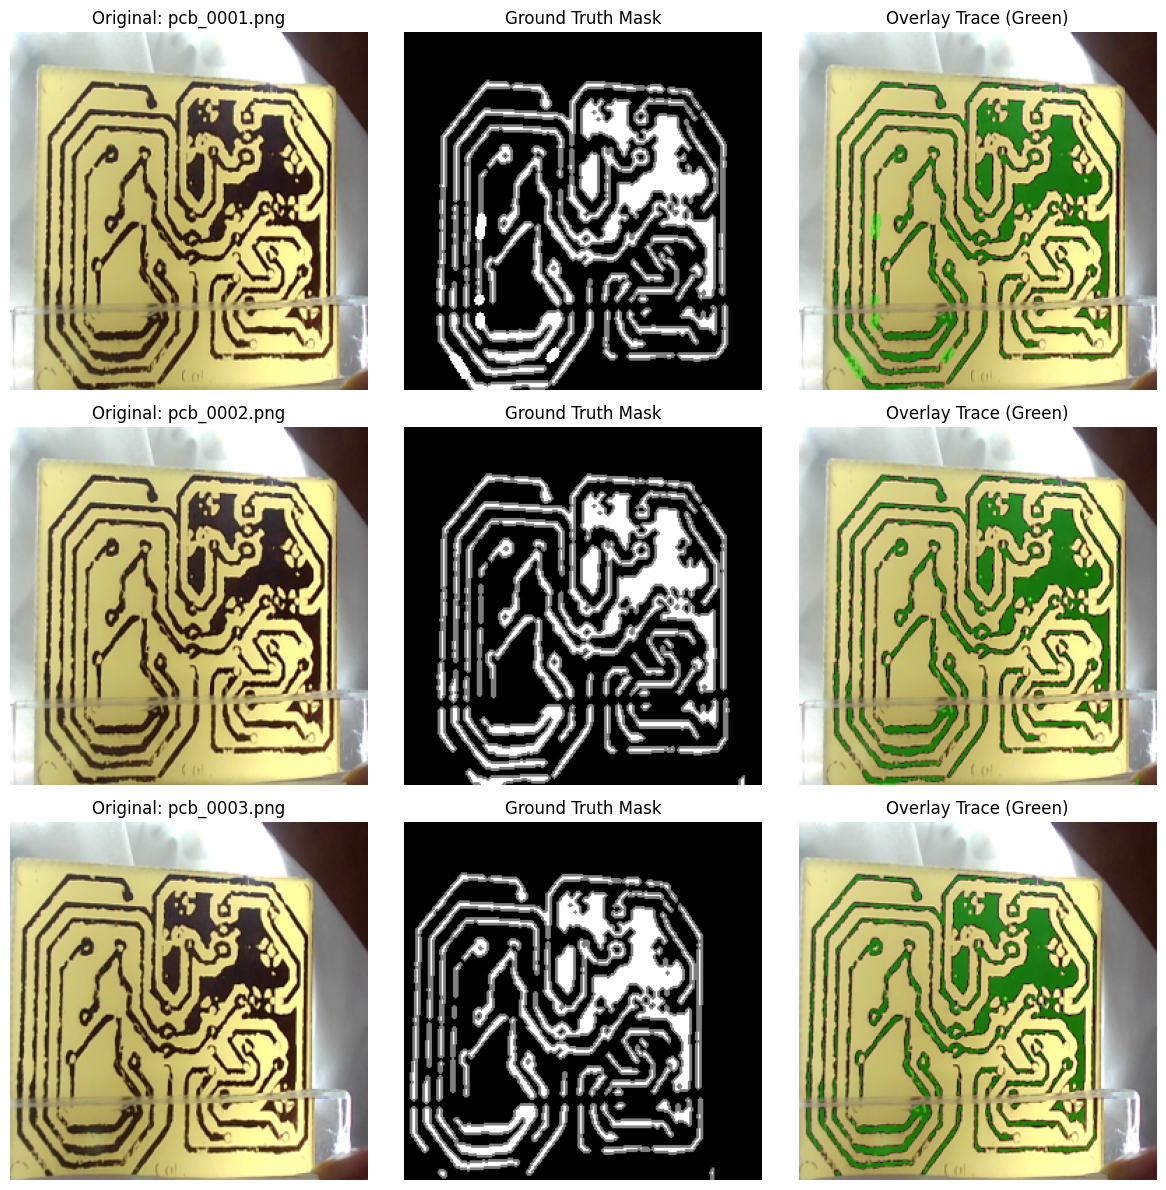

In [29]:
def assemble_dataset(dataset_dir=DATASET_DIR, n_synthetic=N_SYNTHETIC):
    img_dir = os.path.join(dataset_dir, "images")
    mask_dir = os.path.join(dataset_dir, "masks")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)

    real_images = sorted(glob.glob(os.path.join(img_dir, "pcb_*.png")))
    existing_syn = sorted(glob.glob(os.path.join(img_dir, "syn_*.png")))

    if n_synthetic > 0 and len(existing_syn) == 0:
        try:
            for p in [str(BASE_DIR), "."]:
                if p not in sys.path: sys.path.insert(0, p)
            import synth as sy
            print(f"⚡ กำลังสร้างภาพลายวงจรสังเคราะห์ (Synthetic PCB) จำนวน {n_synthetic} แผ่น...")
            rng = np.random.default_rng(123)
            for s in range(n_synthetic):
                w = int(rng.integers(320, 480))
                h = int(rng.integers(400, 600))
                design = sy.make_design(1000 + s, W=w, H=h)
                if rng.random() < 0.5:
                    design, _ = sy.add_defects(design, seed=2000 + s)
                m = sy.rough_edges(design, rng)
                rendered = sy.render_board(m, rng, jitter=True)

                cv2.imwrite(os.path.join(img_dir, f"syn_{s:03d}.png"), rendered)
                cv2.imwrite(os.path.join(mask_dir, f"syn_{s:03d}.png"), m)
            print(f"✅ สร้างภาพสังเคราะห์สำเร็จ: {n_synthetic} แผ่น")
        except ImportError:
            print("ℹ️ ไม่พบโมดูล synth.py ข้ามขั้นตอนสร้างภาพสังเคราะห์ (ใช้เฉพาะภาพถ่ายจริง)")

    all_pairs = sorted((p, os.path.join(mask_dir, os.path.basename(p))) for p in glob.glob(os.path.join(img_dir, "*.png")))
    pairs = [(i, m) for i, m in all_pairs if os.path.exists(m)]

    n_real = len([p for p in pairs if "syn_" not in Path(p[0]).name])
    n_syn = len(pairs) - n_real

    print(f"\n📦 ชุดข้อมูล {dataset_dir} พร้อมใช้งาน:")
    print(f"   - ภาพจริงที่ถ่าย: {n_real} แผ่น")
    print(f"   - ภาพสังเคราะห์เสริม: {n_syn} แผ่น")
    print(f"   - รวมทั้งหมด: {len(pairs)} คู่ภาพ-Mask")
    return pairs

def preview_dataset_samples(pairs_list, num_samples=3):
    if not pairs_list:
        print("⚠️ ยังไม่มีคู่ภาพในชุดข้อมูล กรุณาถ่ายภาพก่อน")
        return

    n = min(num_samples, len(pairs_list))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1: axes = np.expand_dims(axes, 0)

    for i in range(n):
        img_p, mask_p = pairs_list[i]
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[mask == 255] = [0, 255, 0]
        blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original: {Path(img_p).name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(blended)
        axes[i, 2].set_title("Overlay Trace (Green)")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# รวบรวมชุดข้อมูล
pairs = assemble_dataset(DATASET_DIR, n_synthetic=N_SYNTHETIC)
if pairs:
    preview_dataset_samples(pairs, num_samples=3)


### 3.1 เครื่องมือแก้ไข & วาด Mask ลายทองแดง (Ground Truth Studio & Trace Drawer)
หากพบภาพใดที่ Mask ยังไม่สมบูรณ์ (เช่น มีเงาสะท้อนจากขาหนีบอะคริลิค หรือขอบไม่เนียน) สามารถเปิดเครื่องมือแก้ไข Mask ที่รวมไว้ใน `unet_model.py` เพื่อแก้ไขได้ทันที:
- **โหมดวาดเส้น [L]**: คลิกจุด 1 -> จุด 2 เพื่อตีเส้นตรงเชื่อมรอยต่อ (กด `SHIFT` ค้างเพื่อล็อคมุม 0°, 45°, 90°)
- **โหมดแปรงอิสระ [D]**: คลิกลากเมาส์เพื่อระบายลายทองแดงแบบพู่กัน
- **โหมดยางลบ [E]**: คลิกลากเมาส์เพื่อลบส่วนที่เกินออก
- **วางภาพต้นแบบ CAD [1-4]**: เลือก Template `TEST1` - `TEST4` ขยับทาบลงบนบอร์ด และกด `[SPACE]` เพื่อล็อคเป็น Mask
- **บันทึก [S] / ถัดไป [N]**: บันทึก Mask ลงโฟลเดอร์โดยตรง (พร้อมสำรองข้อมูลใน `masks_backup/`)


In [35]:
# ✏️ เรียกใช้งาน Trace Drawer & Ground Truth Studio เพื่อเปิดหน้าต่างแก้ไข Mask
from unet_model import run_trace_drawer

# นำเครื่องหมาย # ออกเพื่อเปิดหน้าต่างแก้ไข Mask:
run_trace_drawer(dataset_dir=DATASET_DIR)


📁 โหลดภาพต้นแบบ CAD ได้ 4 แบบ: ['test1', 'test2', 'test3', 'test4']
📖 เปิดภาพ [1/85]: pcb_0001.png | Template: TEST1

  🖥️  PCB Ground Truth Studio & Trace Drawer (ครบจบใน unet_model.py)
  [คลิกซ้าย 1 -> 2]  : ตีเส้นตรง (Line Mode) | กด SHIFT ค้างล็อคมุม 0/45/90°
  [D]                : สลับโหมดแปรงพู่กันอิสระ (Brush Mode) คลิกลากวาดได้เลย
  [E]                : สลับโหมดยางลบ (Eraser Mode) ปาดลบจุดที่ผิดพลาด
  [P]                : สลับโหมดปั๊ม Pad วงกลม / Via
  [W]                : สลับขนาดหัวแปรง / ยางลบ (2, 3, 5, 8, 12, 16 px)
--------------------------------------------------------------------------
  [1], [2], [3], [4] : เลือกภาพต้นแบบ CAD (TEST1, TEST2, TEST3, TEST4)
  [M]                : สลับโหมด MOVE (คลิกลากขยับ Template / ล้อเมาส์ขยาย-ย่อ)
  [คลิกขวาค้างแล้วลาก]: เลื่อนตำแหน่ง Template ได้ทันทีในทุกโหมด!
  [ลูกศร] / [I,K,J,L]: เลื่อนตำแหน่ง ขึ้น-ลง-ซ้าย-ขวา ทีละ 2 พิกเซล
  [R]                : หมุน Template 90 องศา (0°, 90°, 180°, 270°)
  [F] / [V]          : พลิก Template แนว

## 4. Data Augmentation & PyTorch DataLoader
จำลองสภาพแสงเงาพาดเฉียง, ความเอียง, และการสั่นไหวบนสายพานลำเลียงในโรงงาน เพื่อให้โมเดลทนทานต่อสภาวะจริง


In [ ]:
def preprocess(img_bgr):
    """BGR uint8 (H,W,3) → float32 (3,H,W) normalized"""
    x = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    x = (x - NORM_MEAN) / NORM_STD
    return np.ascontiguousarray(x.transpose(2, 0, 1))

def pad_to_multiple(img, m=32):
    h, w = img.shape[:2]
    ph, pw = (-h) % m, (-w) % m
    if ph or pw:
        img = cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_REFLECT_101)
    return img, (h, w)

def quantize_label(lab):
    return np.where(lab >= 192, 255, np.where(lab <= 64, 0, 128)).astype(np.uint8)

def augment_sample(img, lab, crop_size=256, rng=None):
    if rng is None: rng = np.random.default_rng()
    h, w = img.shape[:2]

    if h > crop_size and w > crop_size:
        y0 = int(rng.integers(0, h - crop_size + 1))
        x0 = int(rng.integers(0, w - crop_size + 1))
        img = img[y0:y0+crop_size, x0:x0+crop_size]
        lab = lab[y0:y0+crop_size, x0:x0+crop_size]
    elif h != crop_size or w != crop_size:
        img = cv2.resize(img, (crop_size, crop_size))
        lab = cv2.resize(lab, (crop_size, crop_size), interpolation=cv2.INTER_NEAREST)

    if rng.random() < 0.5:
        img = np.fliplr(img).copy()
        lab = np.fliplr(lab).copy()
    if rng.random() < 0.5:
        img = np.flipud(img).copy()
        lab = np.flipud(lab).copy()
    k_rot = int(rng.integers(0, 4))
    if k_rot > 0:
        img = np.rot90(img, k_rot).copy()
        lab = np.rot90(lab, k_rot).copy()

    img_f = img.astype(np.float32)
    gamma = float(rng.uniform(0.8, 1.25))
    img_f = 255.0 * np.power(np.clip(img_f / 255.0, 0, 1), gamma)
    contrast = float(rng.uniform(0.85, 1.2))
    img_f = np.clip(128.0 + contrast * (img_f - 128.0), 0, 255)

    return img_f.astype(np.uint8), lab


class PCBDataset(Dataset):
    def __init__(self, pairs, is_train=True, crop=CROP, samples_per_image=12):
        self.pairs = pairs
        self.is_train = is_train
        self.crop = crop
        self.samples_per_image = samples_per_image if is_train else 1
        self.rng = np.random.default_rng(42 if not is_train else None)

    def __len__(self):
        return len(self.pairs) * self.samples_per_image

    def __getitem__(self, idx):
        pair_idx = idx % len(self.pairs)
        img_p, mask_p = self.pairs[pair_idx]
        img = cv2.imread(img_p)
        lab = quantize_label(cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE))

        if self.is_train:
            img, lab = augment_sample(img, lab, crop_size=self.crop, rng=self.rng)
        else:
            if img.shape[0] != self.crop or img.shape[1] != self.crop:
                img = cv2.resize(img, (self.crop, self.crop))
                lab = cv2.resize(lab, (self.crop, self.crop), interpolation=cv2.INTER_NEAREST)

        target = (lab == 255).astype(np.float32)
        valid = (lab != 128).astype(np.float32)
        x = torch.from_numpy(preprocess(img))
        y = torch.from_numpy(target)[None]
        v = torch.from_numpy(valid)[None]
        return x, y, v

if len(pairs) > 0:
    rng_split = np.random.default_rng(42)
    indices = rng_split.permutation(len(pairs))
    n_val = max(1, int(len(pairs) * VAL_RATIO))
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    train_pairs = [pairs[i] for i in train_indices]
    val_pairs = [pairs[i] for i in val_indices]

    train_ds = PCBDataset(train_pairs, is_train=True)
    val_ds = PCBDataset(val_pairs, is_train=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=(device=="cuda"))
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=(device=="cuda"))

    print(f"📊 แบ่งชุดข้อมูล: Train {len(train_pairs)} ภาพ ({len(train_ds)} patches) | Val {len(val_pairs)} ภาพ")


## 5. สถาปัตยกรรมโมเดล Tiny U-Net (~1.9M Parameters)
โมเดลขนาดเล็ก (~1.9 ล้านพารามิเตอร์) ประมวลผลได้เร็วมาก (~0.3-0.8 วินาทีต่อภาพบน Raspberry Pi 5 ด้วย ONNX Runtime)


In [ ]:
class ConvBNReLU(nn.Sequential):
    def __init__(self, cin: int, cout: int):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        )

class DoubleConv(nn.Sequential):
    def __init__(self, cin: int, cout: int):
        super().__init__(
            ConvBNReLU(cin, cout),
            ConvBNReLU(cout, cout),
        )

class TinyUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base: int = UNET_BASE, depth: int = 4):
        super().__init__()
        self.base = base
        self.depth = depth
        ch = [base * (2 ** i) for i in range(depth + 1)]

        self.inc = DoubleConv(in_channels, ch[0])
        self.pool = nn.MaxPool2d(2)
        self.downs = nn.ModuleList([DoubleConv(ch[i], ch[i + 1]) for i in range(depth)])
        self.ups = nn.ModuleList([
            nn.ConvTranspose2d(ch[i + 1], ch[i], 2, stride=2)
            for i in reversed(range(depth))
        ])
        self.decs = nn.ModuleList([
            DoubleConv(ch[i] * 2, ch[i])
            for i in reversed(range(depth))
        ])
        self.drop = nn.Dropout2d(0.1)
        self.head = nn.Conv2d(ch[0], out_channels, 1)

    def forward(self, x):
        skips = [self.inc(x)]
        for d in self.downs:
            skips.append(d(self.pool(skips[-1])))
        x = self.drop(skips.pop())
        for up, dec in zip(self.ups, self.decs):
            x = dec(torch.cat([up(x), skips.pop()], dim=1))
        return self.head(x)

model = TinyUNet(base=UNET_BASE).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"🧠 สร้างโมเดล Tiny U-Net สำเร็จ: พารามิเตอร์ทั้งหมด {n_params:.2f}M")


## 6. Loss Function: BCE + Dice + clDice (Topology-preserving)
- **Masked BCE & Dice**: ประเมินความถูกต้องระดับพิกเซล
- **clDice (Centerline Dice)**: สกัดเส้นกึ่งกลาง (Skeleton) มาลงโทษอย่างรุนแรงเมื่อเส้นขาด (Open) หรือช็อต (Short)


In [ ]:
def soft_erode(x):
    p1 = -F.max_pool2d(-x, (3, 1), 1, (1, 0))
    p2 = -F.max_pool2d(-x, (1, 3), 1, (0, 1))
    return torch.min(p1, p2)

def soft_dilate(x):
    return F.max_pool2d(x, 3, 1, 1)

def soft_open(x):
    return soft_dilate(soft_erode(x))

def soft_skel(x, iters=10):
    skel = F.relu(x - soft_open(x))
    for _ in range(iters):
        x = soft_erode(x)
        delta = F.relu(x - soft_open(x))
        skel = skel + F.relu(delta - skel * delta)
    return skel

def cldice_loss(prob, target, valid, iters=10):
    sp = soft_skel(prob * valid, iters)
    st = soft_skel(target * valid, iters)
    tprec = ((sp * target).sum() + 1.0) / (sp.sum() + 1.0)
    tsens = ((st * prob).sum() + 1.0) / (st.sum() + 1.0)
    return 1.0 - 2.0 * tprec * tsens / (tprec + tsens + 1e-7)

def seg_loss(logits, target, valid, w_dice=1.0, w_cl=0.0):
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce * valid).sum() / valid.sum().clamp(min=1.0)

    prob = torch.sigmoid(logits)
    p = prob * valid
    t = target * valid
    dice = 1.0 - (2.0 * (p * t).sum() + 1.0) / (p.sum() + t.sum() + 1.0)

    loss = bce + w_dice * dice
    cl = torch.zeros((), device=logits.device)
    if w_cl > 0:
        cl = cldice_loss(prob, target, valid)
        loss = loss + w_cl * cl

    return loss, {"bce": float(bce.item()), "dice": float(dice.item()), "cl": float(cl.item())}

@torch.no_grad()
def evaluate_val_metrics(model, loader, device, thr=0.5):
    model.eval()
    total_iou, total_dice, count = 0.0, 0.0, 0
    for x, y, v in loader:
        x, y, v = x.to(device), y.to(device), v.to(device)
        prob = torch.sigmoid(model(x))
        p_bin = (prob >= thr).float() * v
        t_bin = y * v

        inter = (p_bin * t_bin).sum(dim=[1, 2, 3])
        union = (p_bin + t_bin).clamp(max=1.0).sum(dim=[1, 2, 3])
        iou = (inter + 1e-6) / (union + 1e-6)
        dice = (2.0 * inter + 1e-6) / (p_bin.sum(dim=[1, 2, 3]) + t_bin.sum(dim=[1, 2, 3]) + 1e-6)

        total_iou += float(iou.mean().item())
        total_dice += float(dice.mean().item())
        count += 1

    return {"val_iou": total_iou / max(1, count), "val_dice": total_dice / max(1, count)}


## 7. เริ่มต้นการฝึกสอนโมเดล (Training Loop)
ใช้ AdamW Optimizer ร่วมกับ OneCycleLR Scheduler และบันทึก Best Model Checkpoint


In [ ]:
if len(pairs) == 0:
    print("⚠️ ยังไม่มีภาพในชุดข้อมูล กรุณาถ่ายภาพที่เซลล์ที่ 8 ก่อนเริ่มเทรน")
else:
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    total_steps = max(1, len(train_loader)) * EPOCHS
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=total_steps, pct_start=0.15)

    history = []
    best_val_dice = 0.0

    print(f"🚀 เริ่มต้นการฝึกสอน: {EPOCHS} Epochs บน {device.upper()}...")
    print("=" * 68)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_bce, running_dice, running_cl = 0.0, 0.0, 0.0, 0.0
        w_cl = W_CLDICE if epoch > CL_WARMUP else 0.0

        for x, y, v in train_loader:
            x, y, v = x.to(device), y.to(device), v.to(device)
            opt.zero_grad()
            logits = model(x)
            loss, parts = seg_loss(logits, y, v, w_dice=1.0, w_cl=w_cl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

            running_loss += loss.item()
            running_bce += parts["bce"]
            running_dice += parts["dice"]
            running_cl += parts["cl"]

        n_batches = len(train_loader)
        train_loss = running_loss / max(1, n_batches)
        val_metrics = evaluate_val_metrics(model, val_loader, device)

        val_dice = val_metrics["val_dice"]
        val_iou = val_metrics["val_iou"]

        saved_str = ""
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({"model": model.state_dict(), "base": UNET_BASE, "epoch": epoch, "dice": val_dice}, MODEL_PATH)
            saved_str = "⭐ Best Model Saved!"

        history.append({
            "epoch": epoch,
            "loss": train_loss,
            "val_dice": val_dice,
            "val_iou": val_iou
        })

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS or saved_str:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} {saved_str}")

    print("\n" + "=" * 68)
    print(f"🎉 การฝึกสอนเสร็จสิ้น! Best Validation Dice: {best_val_dice:.4f}")
    print(f"💾 บันทึกโมเดลไว้ที่: {MODEL_PATH}")


## 8. กราฟสรุปผลการเทรน และทดสอบ Visual Segmentation
แสดงเส้นโค้งการเรียนรู้ และนำภาพ Validation มาทำนายผลเปรียบเทียบกับของจริง


In [ ]:
if 'history' in locals() and history:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = [h["epoch"] for h in history]
    ax[0].plot(epochs_range, [h["loss"] for h in history], label="Train Loss", color="royalblue")
    ax[0].set_title("Training Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(epochs_range, [h["val_dice"] for h in history], label="Val Dice Score", color="forestgreen")
    ax[1].plot(epochs_range, [h["val_iou"] for h in history], label="Val IoU", color="darkorange")
    ax[1].set_title("Validation Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()
    plt.tight_layout()
    plt.show()

if 'val_pairs' in locals() and val_pairs:
    model.eval()
    samples_to_show = min(3, len(val_pairs))
    fig, axes = plt.subplots(samples_to_show, 4, figsize=(16, 4 * samples_to_show))
    if samples_to_show == 1: axes = np.expand_dims(axes, 0)

    for i in range(samples_to_show):
        ip, mp = val_pairs[i]
        img = cv2.imread(ip)
        gt = quantize_label(cv2.imread(mp, cv2.IMREAD_GRAYSCALE))

        im_pad, (h, w) = pad_to_multiple(img, 32)
        inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(inp))[0, 0, :h, :w].cpu().numpy()
        pred_bin = (prob >= 0.5).astype(np.uint8) * 255

        axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Input: {Path(ip).name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].set_title("AI Prediction")
        axes[i, 2].axis("off")

        diff = np.zeros_like(img)
        diff[(pred_bin == 255) & (gt == 255)] = [0, 255, 0]    # ถูกต้อง (เขียว)
        diff[(pred_bin == 255) & (gt == 0)] = [0, 0, 255]      # เกิน (แดง)
        diff[(pred_bin == 0) & (gt == 255)] = [255, 0, 0]      # ขาด (น้ำเงิน)
        axes[i, 3].imshow(diff)
        axes[i, 3].set_title("Comparison Overlay (Green=OK)")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


## 9. ทดสอบ False Alarm เชิง Topology (Open / Short Circuit Check)
วิเคราะห์ผลทำนายเชิงโครงสร้าง Topology เพื่อยืนยันว่าไม่มีจุดลายวงจรขาด (Open Circuit) หรือลัดวงจร (Short Circuit)


In [ ]:
def mask_iou(a, b, r=0):
    a = dil((a > 127).astype(np.uint8), r)
    b = dil((b > 127).astype(np.uint8), r)
    inter = np.logical_and(a, b).sum()
    uni = np.logical_or(a, b).sum()
    return float(inter) / max(1, uni)

if 'val_pairs' in locals() and val_pairs:
    print("🧪 กำลังทดสอบ Topology Defect Check บน Validation Set...")
    print("=" * 65)

    model.eval()
    for ip, mp in val_pairs[:min(5, len(val_pairs))]:
        img = cv2.imread(ip)
        gt = (quantize_label(cv2.imread(mp, 0)) == 255).astype(np.uint8) * 255

        im_pad, (h, w) = pad_to_multiple(img, 32)
        inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(inp))[0, 0, :h, :w].cpu().numpy()
        pred = (prob >= 0.5).astype(np.uint8) * 255

        iou_val = mask_iou(gt, pred, r=2)
        n_gt_nets = cv2.connectedComponents(gt)[0] - 1
        n_pred_nets = cv2.connectedComponents(pred)[0] - 1

        status = "✅ PASS" if abs(n_gt_nets - n_pred_nets) <= 1 and iou_val > 0.85 else "⚠️ CHECK"
        print(f"[{status}] {Path(ip).name:16s} | IoU: {iou_val:.4f} | Nets GT: {n_gt_nets} -> AI: {n_pred_nets}")


## 10. ส่งออกโมเดลเป็น ONNX (Export for Raspberry Pi 5 & Production)
แปลงโมเดล `.pt` เป็น `.onnx` แบบ Dynamic Axes สำหรับนำไปรันบน Raspberry Pi 5 หรือ Backend


In [ ]:
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    model_cpu = TinyUNet(base=checkpoint.get("base", UNET_BASE))
    model_cpu.load_state_dict(checkpoint["model"])
    model_cpu.eval()

    dummy_input = torch.randn(1, 3, 256, 256)
    kw = dict(
        input_names=["image"],
        output_names=["logits"],
        opset_version=17,
        dynamic_axes={
            "image": {2: "h", 3: "w"},
            "logits": {2: "h", 3: "w"}
        }
    )

    print(f"🚀 กำลัง Export เป็น ONNX ไปยัง: {ONNX_PATH}...")
    try:
        torch.onnx.export(model_cpu, dummy_input, ONNX_PATH, dynamo=False, **kw)
    except TypeError:
        torch.onnx.export(model_cpu, dummy_input, ONNX_PATH, **kw)

    onnx_size_mb = os.path.getsize(ONNX_PATH) / 1e6
    print(f"✅ บันทึกไฟล์ ONNX สำเร็จ: {ONNX_PATH} (ขนาด {onnx_size_mb:.2f} MB)")

    try:
        import onnxruntime as ort
        sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
        test_arr = np.random.randn(1, 3, 256, 256).astype(np.float32)
        res = sess.run(None, {"image": test_arr})[0]
        print(f"🎉 ONNX Runtime ทดสอบผ่านฉลุย! Output shape: {res.shape}")
    except ImportError:
        print("ℹ️ ติดตั้ง onnxruntime เพื่อทดสอบ inference: pip install onnxruntime")
else:
    print(f"⚠️ ยังไม่พบไฟล์ {MODEL_PATH} กรุณาฝึกสอนโมเดลก่อนทำการ Export")


## 11. ระบบตรวจจับแผ่น PCB & ตัดพื้นหลังออกตอนตรวจสอบ (Auto PCB Detection & Inference)
> **ตรงตามที่ต้องการ**: ตอนถ่าย Dataset เก็บภาพผ่านกล้องแบบปกติด้วยกรอบเล็งเป้า  
> **ส่วนขั้นตอนนี้คือการตรวจสอบ (Detection)**: ระบบจะตรวจหาแผ่น PCB สดๆ ตัดพื้นหลัง (โต๊ะ/สายพาน) ออก 100% แล้วดึงเฉพาะตัวบอร์ดส่งเข้า AI เพื่อทำนายลายทองแดง!


In [ ]:
def extract_pcb_board(frame, target_size=(256, 256), min_area_ratio=0.03):
    """
    ฟังก์ชันตรวจจับและดึงเฉพาะพื้นที่บอร์ด PCB ออกมาจากภาพ/กล้อง โดยตัดพื้นหลังออกทั้งหมด:
    - รองรับทั้งไฟส่องทะลุ (Backlit) และไฟส่องตรง (Frontlit)
    - ตรวจจับขอบเขตเนื้อบอร์ด FR4 Substrate + ลายทองแดง แยกออกจากพื้นหลัง
    - หาจุดมุมทั้ง 4 มุม (Corners) และดัดมุมมองตรงด้วย Perspective Warp
    - คืนค่า: (warped_pcb, ordered_quad, board_mask_orig)
    """
    h, w = frame.shape[:2]
    b, g, r = cv2.split(frame)
    diff_rb = r.astype(int) - b.astype(int)
    diff_gb = g.astype(int) - b.astype(int)
    hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (5, 5), 0), cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # 1. ตรวจจับเนื้อบอร์ด (รองรับทั้งไฟส่องทะลุ Backlit และไฟส่องตรง Frontlit)
    is_sub_backlit = (H >= 17) & (H <= 43) & (S >= 35) & (V >= 70) & (diff_gb > 15) & (diff_rb > 20)
    is_frontlit = ((H <= 45) | (H >= 165)) & (S >= 35) & (V >= 50) & (diff_rb > 20)
    board_seed = (is_sub_backlit | is_frontlit).astype(np.uint8) * 255

    board_seed = cv2.morphologyEx(board_seed, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    k = max(21, int(round(min(h, w) * 0.08))) | 1
    board_closed = cv2.morphologyEx(board_seed, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (k, k)))

    cnts, _ = cv2.findContours(board_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, None, None

    largest = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < min_area_ratio * h * w:
        return None, None, None

    hull = cv2.convexHull(largest)
    rect = cv2.minAreaRect(hull)
    peri = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.03 * peri, True)

    if len(approx) == 4:
        quad = approx.reshape(4, 2).astype(np.float32)
    else:
        quad = cv2.boxPoints(rect).astype(np.float32)

    # จัดเรียง 4 จุด: บนซ้าย, บนขวา, ล่างขวา, ล่างซ้าย
    s = quad.sum(axis=1)
    diff = np.diff(quad, axis=1)
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = quad[np.argmin(s)]
    ordered[2] = quad[np.argmax(s)]
    ordered[1] = quad[np.argmin(diff)]
    ordered[3] = quad[np.argmax(diff)]

    # ทำ Perspective Warp ตัดพื้นหลังออก เอาเฉพาะตัวบอร์ดขนาดเป้าหมาย
    tw, th = target_size
    dst = np.array([[0, 0], [tw - 1, 0], [tw - 1, th - 1], [0, th - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(ordered, dst)
    warped = cv2.warpPerspective(frame, M, (tw, th), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    # สร้าง Mask ของตัวบอร์ดบนเฟรมต้นฉบับ
    board_mask_orig = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(board_mask_orig, [ordered.astype(np.int32)], 255)

    return warped, ordered, board_mask_orig


## 12. ทดสอบ Live Camera Inference (ตรวจจับแผ่น PCB & ไฮไลท์ลายทองแดง)
รันเซลล์นี้เพื่อเปิดกล้องตรวจเช็คบอร์ดสดแบบเรียลไทม์:
- **ฝั่งซ้าย**: ภาพกล้องสด ล็อคกรอบสีเขียวรอบบอร์ด PCB และหรี่แสงพื้นหลังลง (Background Dimmed)
- **ฝั่งขวา**: **ภาพตัวบอร์ด PCB เดี่ยวๆ ที่ตัดพื้นหลังออกแล้ว พร้อมไฮไลท์ลายทองแดงสีเขียวสดที่ AI ตรวจพบ!**


In [ ]:
def test_live_camera_inference(model_path=MODEL_PATH, cam_idx=None, conf_thresh=0.5):
    """
    เปิดกล้องสด ตรวจจับดึงเฉพาะแผ่น PCB ออกมาจากพื้นหลัง และรัน AI ทำนายลายทองแดงแบบ Real-Time
    กด [Q] เพื่อออกจากโปรแกรม
    """
    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดลที่: {model_path} กรุณาเทรนโมเดลก่อน")
        return

    active_cam = find_working_camera(cam_idx)
    if active_cam is None:
        print("❌ ไม่พบกล้องที่เปิดใช้งานได้")
        return

    print("🧠 กำลังโหลดโมเดลเข้า GPU/CPU...")
    ckpt = torch.load(model_path, map_location=device)
    m = TinyUNet(base=ckpt.get("base", UNET_BASE)).to(device)
    m.load_state_dict(ckpt["model"])
    m.eval()

    cap = cv2.VideoCapture(active_cam)
    win_name = "PCB AI Live Inspection (Auto Background-Removal)"
    cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win_name, 1024, 512)

    print("\n" + "=" * 65)
    print("  🔍 เริ่มต้น Live PCB Detection (ดึงเฉพาะตัวบอร์ด ตัดพื้นหลังออก)")
    print("  กด [Q] เพื่อออกจากโปรแกรม")
    print("=" * 65 + "\n")

    while True:
        ret, frame = cap.read()
        if not ret: break

        h, w = frame.shape[:2]
        warped_pcb, quad, bmask = extract_pcb_board(frame, target_size=(256, 256))

        t0 = time.time()
        pcb_view = np.zeros((h, h, 3), dtype=np.uint8)

        if warped_pcb is not None:
            # 1. รัน AI บนตัวบอร์ด PCB ที่ตัดพื้นหลังแล้วเท่านั้น!
            im_pad, _ = pad_to_multiple(warped_pcb, 32)
            inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
            with torch.no_grad():
                prob = torch.sigmoid(m(inp))[0, 0, :256, :256].cpu().numpy()

            mask = (prob >= conf_thresh).astype(np.uint8) * 255
            overlay = warped_pcb.copy()
            overlay[mask > 127] = [0, 255, 0]  # ไฮไลท์ลายทองแดงสีเขียว
            blended_pcb = cv2.addWeighted(warped_pcb, 0.5, overlay, 0.5, 0)
            pcb_view = cv2.resize(blended_pcb, (h, h))

            # 2. หรี่แสงพื้นหลังบนกล้องสดลง 60% และวาดกรอบบอร์ด
            bg_dim = cv2.addWeighted(frame, 0.4, np.zeros_like(frame), 0.6, 0)
            frame_view = np.where(bmask[:, :, None] > 0, frame, bg_dim)
            pts = quad.astype(np.int32).reshape((-1, 1, 2))
            cv2.polylines(frame_view, [pts], True, (0, 255, 0), 2)
            cv2.putText(frame_view, "PCB Detected (No BG)", (int(quad[0][0]), max(25, int(quad[0][1]) - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        else:
            frame_view = frame.copy()
            cv2.putText(frame_view, "Searching for PCB...", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
            cv2.putText(pcb_view, "Waiting for PCB...", (h//4, h//2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (120, 120, 120), 2)

        fps = 1.0 / max(1e-4, time.time() - t0)
        cv2.putText(frame_view, f"FPS: {fps:.1f}", (15, h - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # รวมภาพสองฝั่ง: ซ้าย=กล้องสดหรี่พื้นหลัง, ขวา=เฉพาะบอร์ด PCB ที่ตัดพื้นหลังแล้ว
        combined = np.hstack([frame_view, pcb_view])
        cv2.imshow(win_name, combined)

        if cv2.waitKey(1) & 0xFF in [ord('q'), 27]:
            break

    cap.release()
    cv2.destroyAllWindows()
    print("👋 ปิด Live Camera Inference เรียบร้อย")

# รันเพื่อเปิดกล้องสดตรวจจับ PCB แบบตัดพื้นหลัง (นำเครื่องหมาย # ออกเมื่อต้องการทดสอบ)
# test_live_camera_inference()
